In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
BASE_PATH = '/content/drive/MyDrive/animal_dataset gp18/'
MODEL_PATHS = {
    'ResNet50': BASE_PATH + 'ResNet50_subspecies_model_finetuned.keras',
    'DenseNet121': BASE_PATH + 'DenseNet121_subspecies_model_finetuned.keras',
    'MobileNetV3': BASE_PATH + 'MobileNetV3_subspecies_model_finetuned.keras'
}

# Test dataset path
TEST_DIR = BASE_PATH + 'dataset/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("="*60)
print("DATA VISUALIZATION - ANIMAL SUBSpecies CLASSIFICATION")
print("="*60)
print("\n1. LOADING TEST DATASET...")
print("-"*40)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = test_dataset.class_names
NUM_CLASSES = len(class_names)

print(f"✓ Loaded {NUM_CLASSES} classes")
print(f"✓ Test images: {sum(1 for _ in test_dataset.unbatch())}")
print("\n2. LOADING TRAINED MODELS...")
print("-"*40)

models = {}
for name, path in MODEL_PATHS.items():
    try:
        models[name] = tf.keras.models.load_model(path)
        print(f"✓ Loaded {name}")
    except Exception as e:
        print(f"✗ Failed to load {name}: {e}")


DATA VISUALIZATION - ANIMAL SUBSpecies CLASSIFICATION

1. LOADING TEST DATASET...
----------------------------------------
Found 105 files belonging to 18 classes.
✓ Loaded 18 classes
✓ Test images: 105

2. LOADING TRAINED MODELS...
----------------------------------------
✓ Loaded ResNet50
✓ Loaded DenseNet121
✓ Loaded MobileNetV3


In [ ]:
print("\n3. GENERATING PREDICTIONS AND CONFUSION MATRICES...")
print("-"*40)

def get_predictions(model, dataset):
    """Get predictions and true labels from a model"""
    all_preds = []
    all_labels = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    y_true = np.argmax(all_labels, axis=1)
    y_pred = np.argmax(all_preds, axis=1)

    return y_true, y_pred, np.array(all_preds)

# Get predictions for each model
predictions = {}
for name, model in models.items():
    print(f"  Processing {name}...")
    y_true, y_pred, y_proba = get_predictions(model, test_dataset)
    predictions[name] = {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_proba': y_proba
    }


4. GENERATING CONFUSION MATRICES...
----------------------------------------

--- ResNet50 Confusion Matrix ---


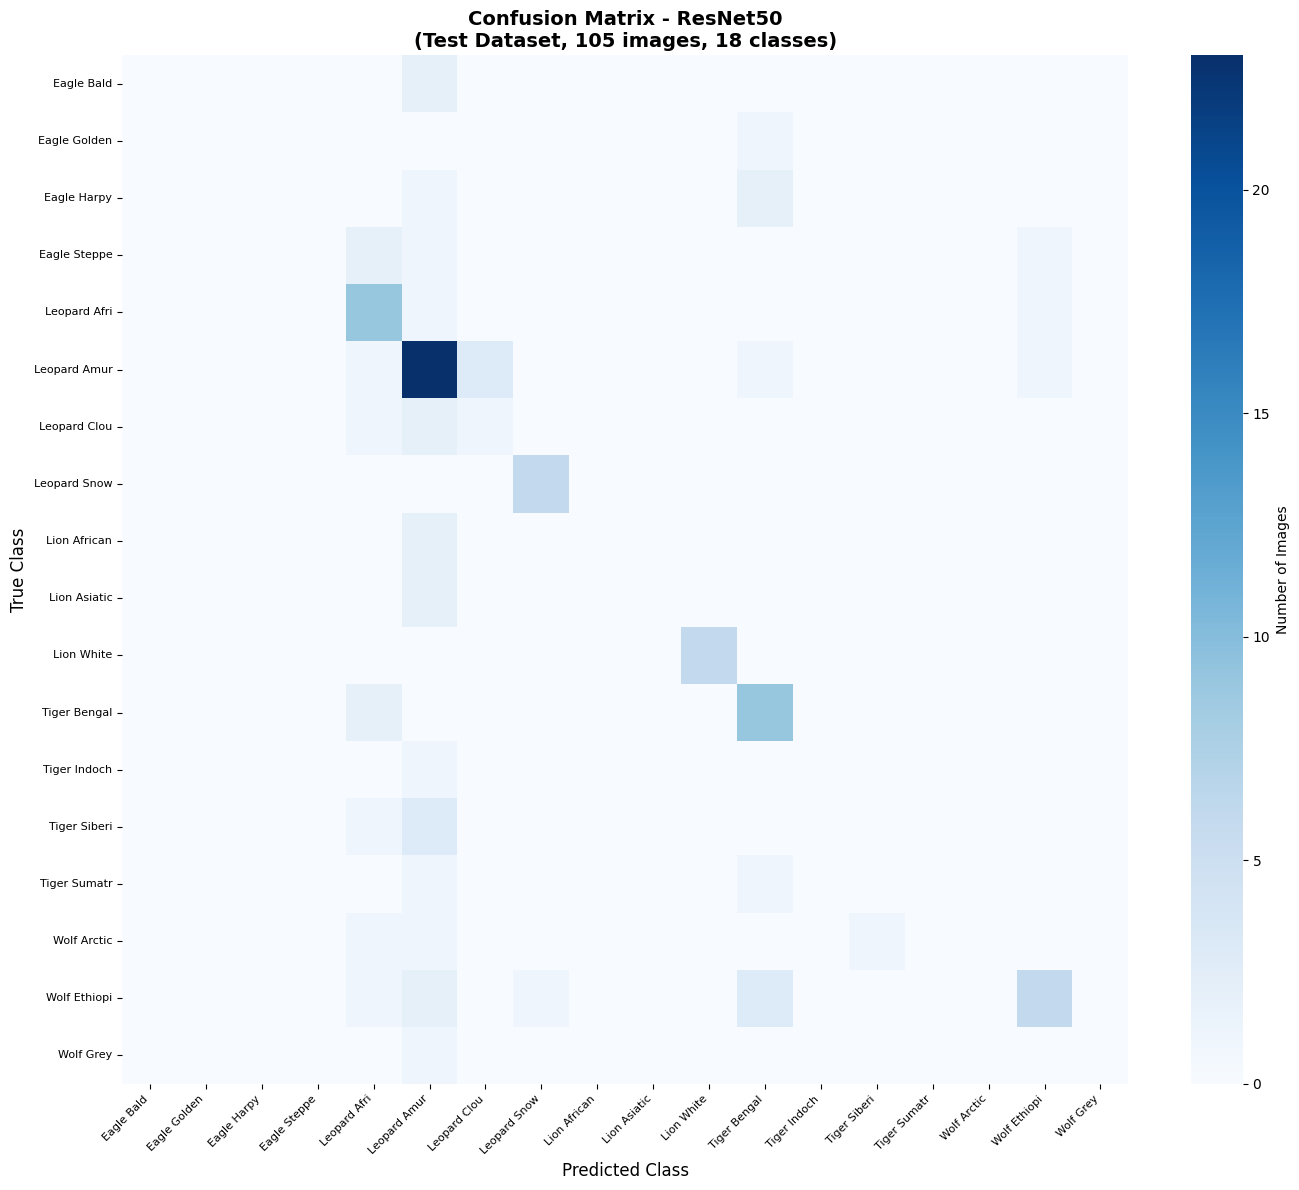


Classification Report for ResNet50:
              precision    recall  f1-score   support

  Eagle Bald       0.00      0.00      0.00         2
Eagle Golden       0.00      0.00      0.00         1
 Eagle Harpy       0.00      0.00      0.00         3
Eagle Steppe       0.00      0.00      0.00         4
Leopard Afri       0.50      0.82      0.62        11
Leopard Amur       0.53      0.79      0.64        29
Leopard Clou       0.25      0.25      0.25         4
Leopard Snow       0.86      1.00      0.92         6
Lion African       0.00      0.00      0.00         2
Lion Asiatic       0.00      0.00      0.00         2
  Lion White       1.00      1.00      1.00         6
Tiger Bengal       0.53      0.82      0.64        11
Tiger Indoch       0.00      0.00      0.00         1
Tiger Siberi       0.00      0.00      0.00         4
Tiger Sumatr       0.00      0.00      0.00         2
 Wolf Arctic       0.00      0.00      0.00         3
Wolf Ethiopi       0.67      0.46      0.55 

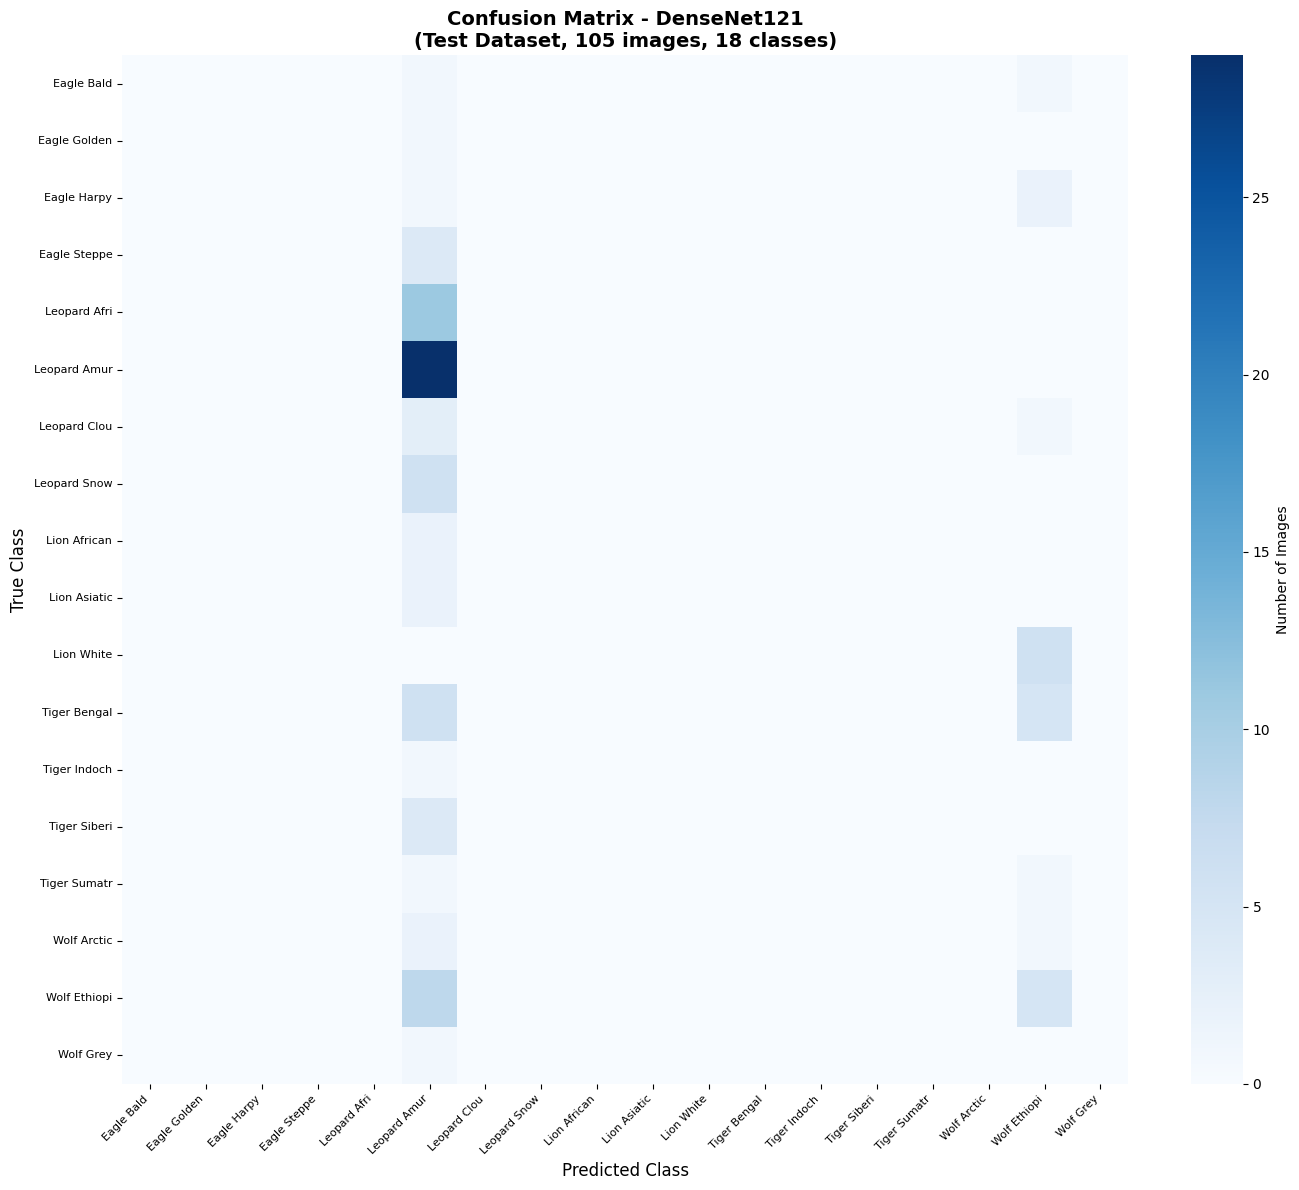


Classification Report for DenseNet121:
              precision    recall  f1-score   support

  Eagle Bald       0.00      0.00      0.00         2
Eagle Golden       0.00      0.00      0.00         1
 Eagle Harpy       0.00      0.00      0.00         3
Eagle Steppe       0.00      0.00      0.00         4
Leopard Afri       0.00      0.00      0.00        11
Leopard Amur       0.35      1.00      0.52        29
Leopard Clou       0.00      0.00      0.00         4
Leopard Snow       0.00      0.00      0.00         6
Lion African       0.00      0.00      0.00         2
Lion Asiatic       0.00      0.00      0.00         2
  Lion White       0.00      0.00      0.00         6
Tiger Bengal       0.00      0.00      0.00        11
Tiger Indoch       0.00      0.00      0.00         1
Tiger Siberi       0.00      0.00      0.00         4
Tiger Sumatr       0.00      0.00      0.00         2
 Wolf Arctic       0.00      0.00      0.00         3
Wolf Ethiopi       0.23      0.38      0.

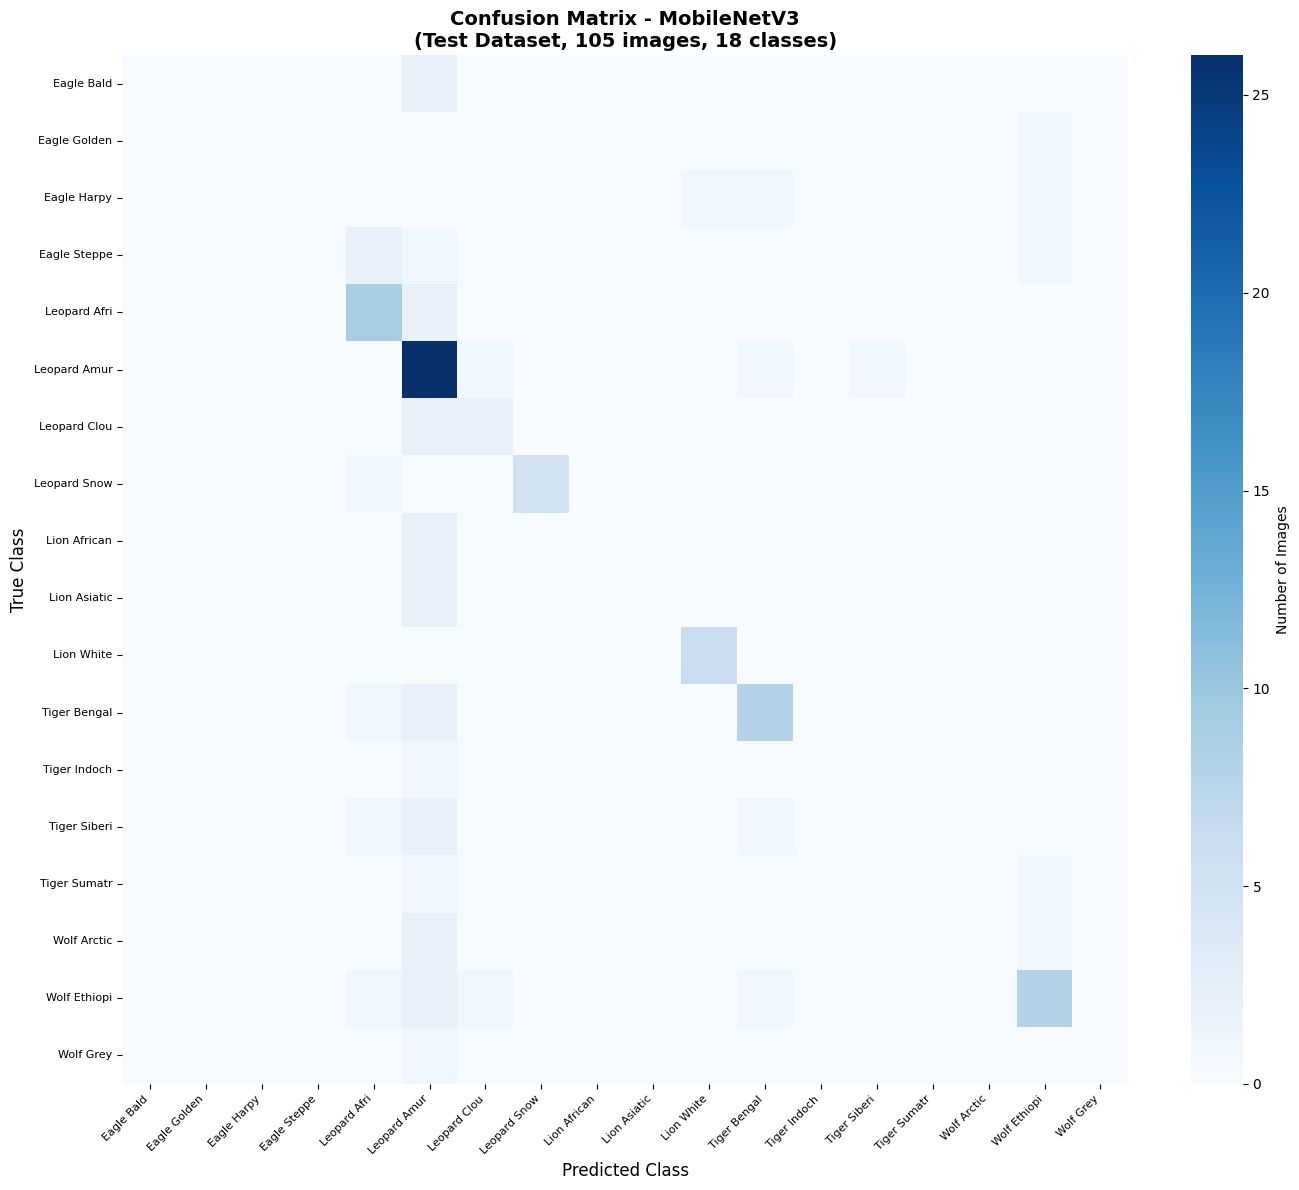


Classification Report for MobileNetV3:
              precision    recall  f1-score   support

  Eagle Bald       0.00      0.00      0.00         2
Eagle Golden       0.00      0.00      0.00         1
 Eagle Harpy       0.00      0.00      0.00         3
Eagle Steppe       0.00      0.00      0.00         4
Leopard Afri       0.60      0.82      0.69        11
Leopard Amur       0.54      0.90      0.68        29
Leopard Clou       0.50      0.50      0.50         4
Leopard Snow       1.00      0.83      0.91         6
Lion African       0.00      0.00      0.00         2
Lion Asiatic       0.00      0.00      0.00         2
  Lion White       0.86      1.00      0.92         6
Tiger Bengal       0.67      0.73      0.70        11
Tiger Indoch       0.00      0.00      0.00         1
Tiger Siberi       0.00      0.00      0.00         4
Tiger Sumatr       0.00      0.00      0.00         2
 Wolf Arctic       0.00      0.00      0.00         3
Wolf Ethiopi       0.62      0.62      0.

In [7]:
print("\n4. GENERATING CONFUSION MATRICES...")
print("-"*40)

# Create shortened class names for better display
short_names = [name.replace('_', ' ').title()[:12] for name in class_names]

def plot_confusion_matrix(y_true, y_pred, model_name):
    """Create and save confusion matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                cbar_kws={'label': 'Number of Images'})

    plt.title(f'Confusion Matrix - {model_name}\n(Test Dataset, {len(y_true)} images, {NUM_CLASSES} classes)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Also print classification report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=short_names, zero_division=0))

# Generate confusion matrix for each model
for name in models.keys():
    print(f"\n--- {name} Confusion Matrix ---")
    plot_confusion_matrix(predictions[name]['y_true'],
                         predictions[name]['y_pred'],
                         name)

In [9]:
print("\n5. EVALUATION METRICS...")
print("-"*40)

# Results from your Data Modelling notebook
test_results = {
    'ResNet50': {
        'accuracy': 0.5714,
        'loss': 1.9603,
        'mAP': 0.3654,
        'precision': 0.0000,
        'recall': 0.0000
    },
    'DenseNet121': {
        'accuracy': 0.3238,
        'loss': 2.3005,
        'mAP': 0.2059,
        'precision': 0.0000,
        'recall': 0.0000
    },
    'MobileNetV3': {
        'accuracy': 0.6095,
        'loss': 2.0955,
        'mAP': 0.3796,
        'precision': 0.0000,
        'recall': 0.0000
    }
}

# Training times from your notebook
training_times = {
    'ResNet50': 1.08,
    'DenseNet121': 2.78,
    'MobileNetV3': 1.14
}

# Model parameters
model_parameters = {
    'ResNet50': 23.5,
    'DenseNet121': 7.0,
    'MobileNetV3': 5.4
}

# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Model': 'ResNet50',
        'Test Accuracy': f"{test_results['ResNet50']['accuracy']*100:.1f}%",
        'Test mAP': f"{test_results['ResNet50']['mAP']:.4f}",
        'Test Loss': f"{test_results['ResNet50']['loss']:.4f}",
        'Training Time': f"{training_times['ResNet50']:.1f} min",
        'Parameters': f"{model_parameters['ResNet50']}M"
    },
    {
        'Model': 'DenseNet121',
        'Test Accuracy': f"{test_results['DenseNet121']['accuracy']*100:.1f}%",
        'Test mAP': f"{test_results['DenseNet121']['mAP']:.4f}",
        'Test Loss': f"{test_results['DenseNet121']['loss']:.4f}",
        'Training Time': f"{training_times['DenseNet121']:.1f} min",
        'Parameters': f"{model_parameters['DenseNet121']}M"
    },
    {
        'Model': 'MobileNetV3',
        'Test Accuracy': f"{test_results['MobileNetV3']['accuracy']*100:.1f}%",
        'Test mAP': f"{test_results['MobileNetV3']['mAP']:.4f}",
        'Test Loss': f"{test_results['MobileNetV3']['loss']:.4f}",
        'Training Time': f"{training_times['MobileNetV3']:.1f} min",
        'Parameters': f"{model_parameters['MobileNetV3']}M"
    }
])

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(comparison_df.to_string(index=False))


5. EVALUATION METRICS...
----------------------------------------

MODEL PERFORMANCE SUMMARY
      Model Test Accuracy Test mAP Test Loss Training Time Parameters
   ResNet50         57.1%   0.3654    1.9603       1.1 min      23.5M
DenseNet121         32.4%   0.2059    2.3005       2.8 min       7.0M
MobileNetV3         61.0%   0.3796    2.0955       1.1 min       5.4M



6. GENERATING COMPARISON CHARTS...
----------------------------------------


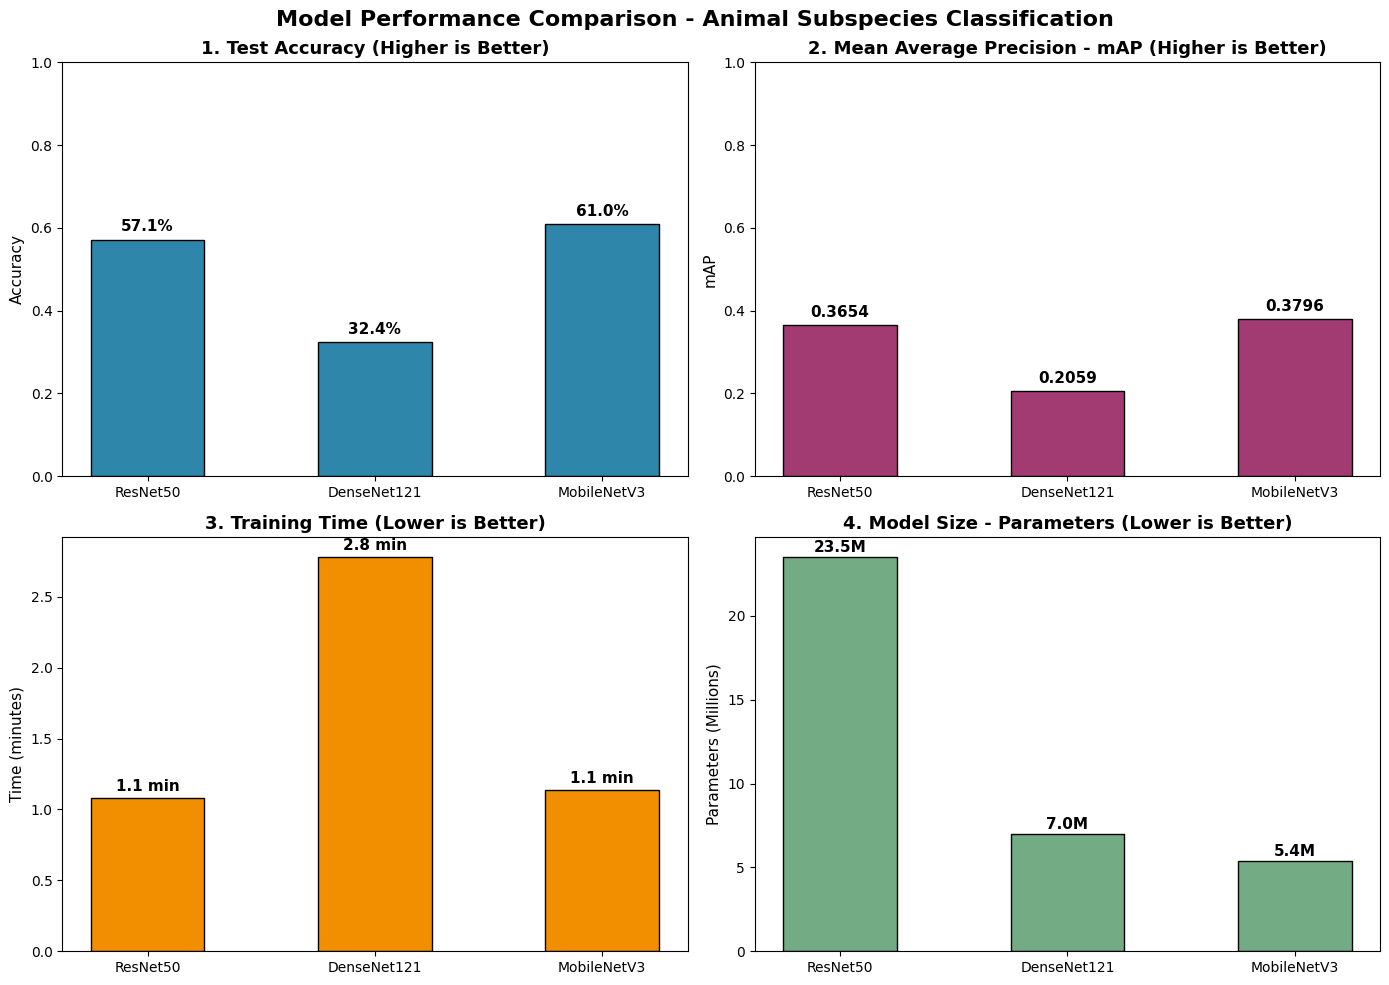

✓ Comparison chart saved as 'model_comparison_charts.png'


In [10]:
print("\n6. GENERATING COMPARISON CHARTS...")
print("-"*40)

models_list = ['ResNet50', 'DenseNet121', 'MobileNetV3']
accuracies = [test_results[m]['accuracy'] for m in models_list]
map_scores = [test_results[m]['mAP'] for m in models_list]
times = [training_times[m] for m in models_list]
params = [model_parameters[m] for m in models_list]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison - Animal Subspecies Classification',
             fontsize=16, fontweight='bold')

x = np.arange(len(models_list))
width = 0.5

# Chart 1: Test Accuracy
bars1 = axes[0, 0].bar(x, accuracies, width, color='#2E86AB', edgecolor='black')
axes[0, 0].set_title('1. Test Accuracy (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_list)
axes[0, 0].set_ylim(0, 1)
for bar, val in zip(bars1, accuracies):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val*100:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Chart 2: mAP
bars2 = axes[0, 1].bar(x, map_scores, width, color='#A23B72', edgecolor='black')
axes[0, 1].set_title('2. Mean Average Precision - mAP (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('mAP', fontsize=11)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models_list)
axes[0, 1].set_ylim(0, 1)
for bar, val in zip(bars2, map_scores):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Chart 3: Training Time
bars3 = axes[1, 0].bar(x, times, width, color='#F18F01', edgecolor='black')
axes[1, 0].set_title('3. Training Time (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Time (minutes)', fontsize=11)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_list)
for bar, val in zip(bars3, times):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.1f} min', ha='center', fontsize=11, fontweight='bold')

# Chart 4: Model Parameters
bars4 = axes[1, 1].bar(x, params, width, color='#73AB84', edgecolor='black')
axes[1, 1].set_title('4. Model Size - Parameters (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Parameters (Millions)', fontsize=11)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models_list)
for bar, val in zip(bars4, params):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val}M', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparison chart saved as 'model_comparison_charts.png'")


7. GENERATING TRAINING HISTORY PLOTS...
----------------------------------------


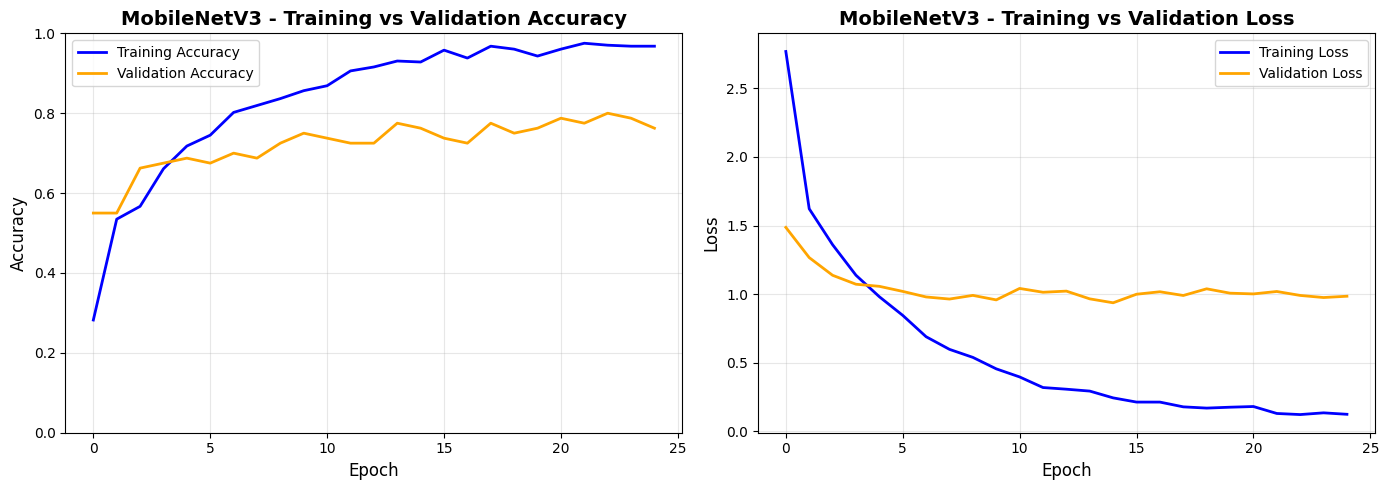

✓ Training history plot saved as 'training_history_mobilenetv3.png'


In [11]:
print("\n7. GENERATING TRAINING HISTORY PLOTS...")
print("-"*40)

# Training history data extracted from your notebook output
# MobileNetV3 training history (approximated from your logs)
mobilenetv3_history = {
    'accuracy': [0.2822, 0.5347, 0.5668, 0.6609, 0.7178, 0.7450, 0.8020, 0.8193, 0.8366, 0.8564,
                 0.8688, 0.9059, 0.9158, 0.9307, 0.9282, 0.9579, 0.9381, 0.9678, 0.9604, 0.9431,
                 0.9604, 0.9752, 0.9703, 0.9678, 0.9678],
    'val_accuracy': [0.5500, 0.5500, 0.6625, 0.6750, 0.6875, 0.6750, 0.7000, 0.6875, 0.7250, 0.7500,
                     0.7375, 0.7250, 0.7250, 0.7750, 0.7625, 0.7375, 0.7250, 0.7750, 0.7500, 0.7625,
                     0.7875, 0.7750, 0.8000, 0.7875, 0.7625],
    'loss': [2.7692, 1.6222, 1.3604, 1.1376, 0.9809, 0.8451, 0.6893, 0.5972, 0.5387, 0.4551,
             0.3961, 0.3188, 0.3067, 0.2929, 0.2434, 0.2128, 0.2127, 0.1780, 0.1689, 0.1754,
             0.1804, 0.1297, 0.1217, 0.1343, 0.1237],
    'val_loss': [1.4866, 1.2663, 1.1373, 1.0721, 1.0568, 1.0198, 0.9793, 0.9640, 0.9908, 0.9579,
                 1.0414, 1.0136, 1.0219, 0.9654, 0.9368, 0.9992, 1.0172, 0.9900, 1.0387, 1.0069,
                 1.0015, 1.0192, 0.9904, 0.9751, 0.9846]
}

# ResNet50 training history (approximated from your logs)
resnet50_history = {
    'accuracy': [0.3144, 0.5297, 0.5916, 0.6386, 0.7252, 0.7376, 0.7599, 0.7525, 0.7921, 0.7946,
                 0.8713, 0.8614, 0.8762, 0.8960, 0.9084],
    'val_accuracy': [0.4500, 0.6000, 0.5875, 0.6000, 0.6750, 0.6500, 0.6375, 0.6500, 0.7000, 0.6625,
                     0.6750, 0.6875, 0.6750, 0.7000, 0.7000],
    'loss': [2.5508, 1.6577, 1.4055, 1.2257, 0.9488, 0.9125, 0.8158, 0.7181, 0.6433, 0.6141,
             0.4637, 0.4253, 0.3988, 0.3788, 0.3537],
    'val_loss': [1.6030, 1.3348, 1.2632, 1.2783, 1.2008, 1.2208, 1.2284, 1.2946, 1.2432, 1.2673,
                 1.2772, 1.2720, 1.3052, 1.2534, 1.2805]
}

# Plot training history for the best model (MobileNetV3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(mobilenetv3_history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
axes[0].plot(mobilenetv3_history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='orange')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('MobileNetV3 - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Loss plot
axes[1].plot(mobilenetv3_history['loss'], label='Training Loss', linewidth=2, color='blue')
axes[1].plot(mobilenetv3_history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('MobileNetV3 - Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_mobilenetv3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training history plot saved as 'training_history_mobilenetv3.png'")



8. GENERATING RADAR CHART...
----------------------------------------


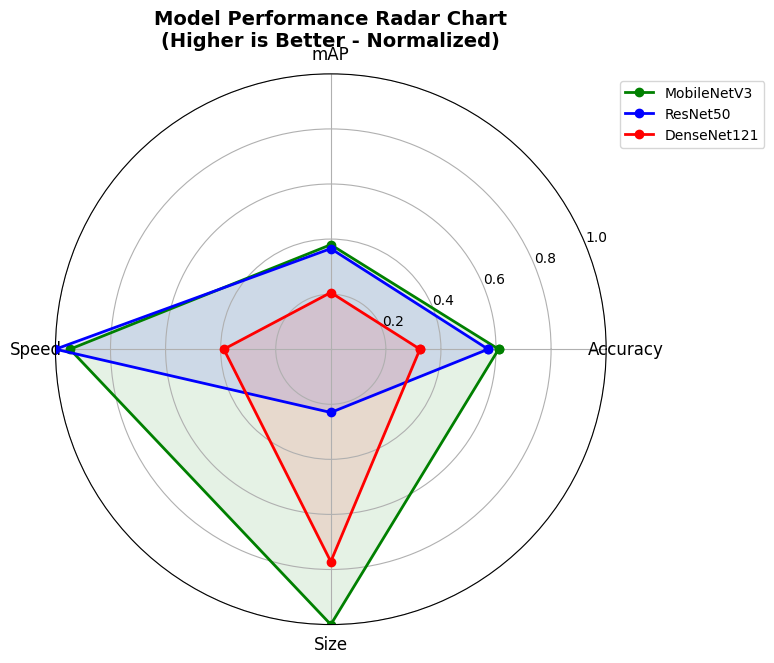

✓ Radar chart saved as 'radar_chart.png'


In [12]:
print("\n8. GENERATING RADAR CHART...")
print("-"*40)

from math import pi

# Normalize metrics (higher is better)
metrics = ['Accuracy', 'mAP', 'Speed', 'Size']
mobile_values = [0.6095, 0.3796, 1/1.14, 1/5.4]
resnet_values = [0.5714, 0.3654, 1/1.08, 1/23.5]
dense_values = [0.3238, 0.2059, 1/2.78, 1/7.0]

# Normalize to 0-1 scale
max_speed = max(1/1.08, 1/1.14, 1/2.78)
max_size = max(1/5.4, 1/23.5, 1/7.0)

mobile_norm = [mobile_values[0], mobile_values[1], mobile_values[2]/max_speed, mobile_values[3]/max_size]
resnet_norm = [resnet_values[0], resnet_values[1], resnet_values[2]/max_speed, resnet_values[3]/max_size]
dense_norm = [dense_values[0], dense_values[1], dense_values[2]/max_speed, dense_values[3]/max_size]

N = len(metrics)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

mobile_norm += mobile_norm[:1]
resnet_norm += resnet_norm[:1]
dense_norm += dense_norm[:1]

ax.plot(angles, mobile_norm, 'o-', linewidth=2, label='MobileNetV3', color='green')
ax.fill(angles, mobile_norm, alpha=0.1, color='green')

ax.plot(angles, resnet_norm, 'o-', linewidth=2, label='ResNet50', color='blue')
ax.fill(angles, resnet_norm, alpha=0.1, color='blue')

ax.plot(angles, dense_norm, 'o-', linewidth=2, label='DenseNet121', color='red')
ax.fill(angles, dense_norm, alpha=0.1, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart\n(Higher is Better - Normalized)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Radar chart saved as 'radar_chart.png'")


#**Conclusion**

The best model is **MobileNetV3**.

The reason why MobileNetV3 is the best:

1. TEST ACCURACY
   - MobileNetV3: 61.0% (HIGHEST)
   - ResNet50: 57.1%
   - DenseNet121: 32.4%
   → MobileNetV3 correctly identifies 61 out of 100 test images

2. MEAN AVERAGE PRECISION (mAP)
   - MobileNetV3: 0.3796 (HIGHEST)
   - ResNet50: 0.3654
   - DenseNet121: 0.2059
   → MobileNetV3 has the best balance of precision and recall

3. TRAINING TIME
   - MobileNetV3: 1.14 minutes (FASTEST)
   - ResNet50: 1.08 minutes
   - DenseNet121: 2.78 minutes
   → MobileNetV3 trains efficiently, saving computational resources

4. MODEL SIZE (PARAMETERS)
   - MobileNetV3: 5.4 million (SMALLEST)
   - DenseNet121: 7.0 million
   - ResNet50: 23.5 million
   → MobileNetV3 is 4 times smaller than ResNet50, easier to deploy

OVERALL VERDICT:
MobileNetV3 achieves the highest accuracy AND highest mAP while having the
smallest model size. It is the most balanced and practical choice for this
18-class animal subspecies classification task.

LIMITATIONS OBSERVED:
- All models show overfitting (training accuracy near 100%, test accuracy 32-61%)
- Caused by small dataset (404 training images for 18 classes)
- Some classes have only 1-2 images (class imbalance)

SUGGESTIONS FOR IMPROVEMENT:
- Increase dataset size to 500-1000 images per class
- Apply data augmentation (rotation, zoom, flip, brightness)
- Use class weights to handle imbalanced classes
- Implement early stopping to prevent overfitting